# Importing the dataset and the necessary libararies

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('walmart-sales-dataset-of-45stores.csv')

# Exploring the dataset

In [3]:
data.info()
data.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106
5,1,12-03-2010,1439541.59,0,57.79,2.667,211.380643,8.106
6,1,19-03-2010,1472515.79,0,54.58,2.720,211.215635,8.106
7,1,26-03-2010,1404429.92,0,51.45,2.732,211.018042,8.106
8,1,02-04-2010,1594968.28,0,62.27,2.719,210.820450,7.808
9,1,09-04-2010,1545418.53,0,65.86,2.770,210.622857,7.808


Are there any null values or duplicates?

In [4]:
data.isna().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

In [5]:
data.duplicated().sum()

0

## Cleaning

In [6]:
data['Date'] = pd.to_datetime(data['Date'], format='mixed')

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(2)
memory usage: 402.3 KB


In [8]:
data.sample(10)

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
5305,38,2010-05-14,346174.30,0,68.44,3.145,126.208548,14.099
2119,15,2012-04-05,577868.38,0,51.04,4.124,138.033200,8.150
1558,11,2012-07-20,1344483.81,0,82.41,3.311,225.443883,6.334
6064,43,2011-03-18,635171.05,0,68.98,3.488,206.225924,10.398
565,4,2012-09-14,2117854.60,0,68.20,3.706,130.977667,4.077
1762,13,2010-12-24,3595903.20,0,34.90,2.846,126.983581,7.795
4608,33,2010-09-17,246277.18,0,89.43,3.028,126.145467,9.495
4615,33,2010-05-11,246124.61,0,74.23,3.009,126.491290,9.265
2796,20,2011-12-08,2052246.40,0,73.52,3.812,208.782006,7.274
5399,38,2012-02-03,471115.38,0,52.27,4.178,130.645793,12.187


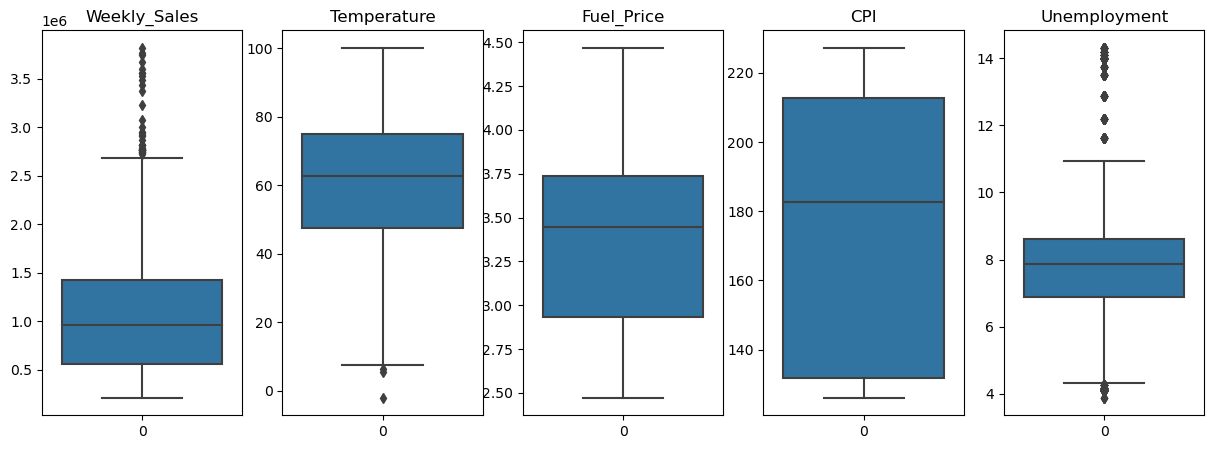

In [9]:
fig, axs = plt.subplots(1, 5, figsize=(15, 5))
sns.boxplot(data['Weekly_Sales'], ax = axs[0])
axs[0].set_title('Weekly_Sales')

sns.boxplot(data['Temperature'], ax = axs[1])
axs[1].set_title('Temperature')

sns.boxplot(data['Fuel_Price'], ax = axs[2])
axs[2].set_title('Fuel_Price')

sns.boxplot(data['CPI'], ax = axs[3])
axs[3].set_title('CPI')

sns.boxplot(data['Unemployment'], ax = axs[4])
axs[4].set_title('Unemployment')

plt.show()

In [10]:
# Calculate the first quartile (Q1) and third quartile (Q3)
Q1 = data['Weekly_Sales'].quantile(0.25)
Q3 = data['Weekly_Sales'].quantile(0.75)

# Calculate the interquartile range (IQR)
IQR = Q3 - Q1

print('Q1: ', Q1)
print('Q3: ', Q3)
print('IQR: ', IQR)

# Define the lower and upper bounds for outlier detection
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR



sales_outliers= data[(data['Weekly_Sales'] < lower_bound) | (data['Weekly_Sales'] > upper_bound)]

sales_outliers.info()
sales_outliers

Q1:  553350.105
Q3:  1420158.66
IQR:  866808.5549999999
<class 'pandas.core.frame.DataFrame'>
Index: 34 entries, 189 to 3816
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         34 non-null     int64         
 1   Date          34 non-null     datetime64[ns]
 2   Weekly_Sales  34 non-null     float64       
 3   Holiday_Flag  34 non-null     int64         
 4   Temperature   34 non-null     float64       
 5   Fuel_Price    34 non-null     float64       
 6   CPI           34 non-null     float64       
 7   Unemployment  34 non-null     float64       
dtypes: datetime64[ns](1), float64(5), int64(2)
memory usage: 2.4 KB


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
189,2,2010-12-24,3436007.68,0,49.97,2.886,211.064660,8.163
241,2,2011-12-23,3224369.80,0,46.66,3.112,218.999550,7.441
471,4,2010-11-26,2789469.45,1,48.08,2.752,126.669267,7.127
474,4,2010-12-17,2740057.14,0,46.57,2.884,126.879484,7.127
475,4,2010-12-24,3526713.39,0,43.21,2.887,126.983581,7.127
523,4,2011-11-25,3004702.33,1,47.96,3.225,129.836400,5.143
526,4,2011-12-16,2771397.17,0,36.44,3.149,129.898065,5.143
527,4,2011-12-23,3676388.98,0,35.92,3.103,129.984548,5.143
761,6,2010-12-24,2727575.18,0,55.07,2.886,212.916508,7.007
1329,10,2010-11-26,2939946.38,1,55.33,3.162,126.669267,9.003


In [11]:
sales_grouped = data.groupby('Date')['Weekly_Sales'].sum().to_frame().reset_index()
sales_grouped

,Date,Weekly_Sales
0,2010-01-10,42239875.87
1,2010-02-04,50423831.26
2,2010-02-07,48917484.50
3,2010-02-19,48276993.78
4,2010-02-26,43968571.13
...,...,...
138,2012-10-08,47403451.04
139,2012-10-19,45122410.57
140,2012-10-26,45544116.29
141,2012-11-05,46925878.99


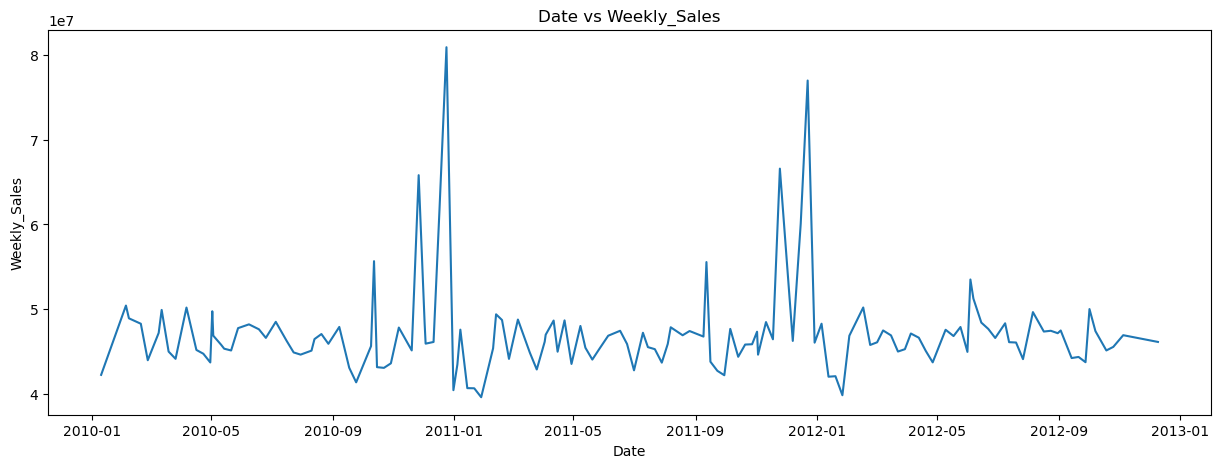

In [12]:
plt.figure(figsize=(15, 5))
plt.plot(sales_grouped['Date'], sales_grouped['Weekly_Sales'])
plt.title('Date vs Weekly_Sales')
plt.xlabel('Date')
plt.ylabel('Weekly_Sales')
plt.show()

## Q1/ Which store has maximum sales?

In [13]:
WS_total_per_store = data.groupby('Store')['Weekly_Sales'].sum().to_frame().reset_index()
WS_total_per_store

,Store,Weekly_Sales
0,1,2.224028e+08
1,2,2.753824e+08
2,3,5.758674e+07
3,4,2.995440e+08
4,5,4.547569e+07
5,6,2.237561e+08
6,7,8.159828e+07
7,8,1.299512e+08
8,9,7.778922e+07
9,10,2.716177e+08


In [14]:
WS_total_per_store.sort_values('Weekly_Sales', ascending = False, inplace=True)
WS_total_per_store.reset_index(drop=True, inplace=True)
WS_total_per_store

,Store,Weekly_Sales
0,20,3.013978e+08
1,4,2.995440e+08
2,14,2.889999e+08
3,13,2.865177e+08
4,2,2.753824e+08
5,10,2.716177e+08
6,27,2.538559e+08
7,6,2.237561e+08
8,1,2.224028e+08
9,39,2.074455e+08


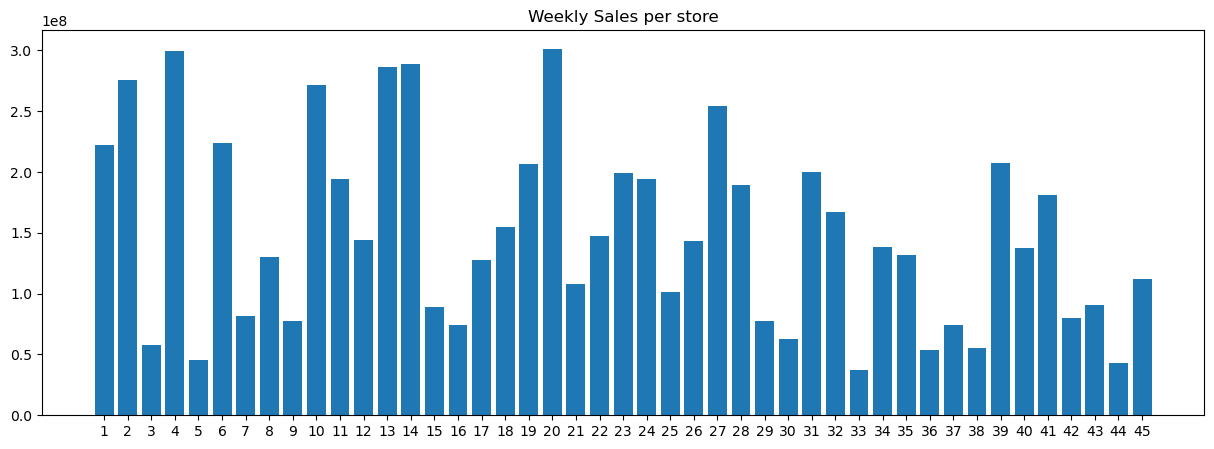

In [15]:
plt.figure(figsize=(15, 5))
plt.bar(WS_total_per_store['Store'], WS_total_per_store['Weekly_Sales'])
plt.xticks(WS_total_per_store['Store'])
plt.title("Weekly Sales per store")
plt.show()

## A/ Store 20 & 4 have the most sales

## Q2/ Which store has maximum standard deviation i.e., the sales vary a lot

In [16]:
WS_std_per_store = data.groupby('Store')['Weekly_Sales'].std().reset_index()
WS_std_per_store.head(6)

,Store,Weekly_Sales
0,1,155980.767761
1,2,237683.694682
2,3,46319.631557
3,4,266201.442297
4,5,37737.965745
5,6,212525.855862


In [17]:
WS_std_per_store.sort_values('Weekly_Sales', ascending=False, inplace=True)
WS_std_per_store = WS_std_per_store.reset_index(drop=True)
WS_std_per_store.head(6)

,Store,Weekly_Sales
0,14,317569.949476
1,10,302262.062504
2,20,275900.562742
3,4,266201.442297
4,13,265506.995776
5,23,249788.038068


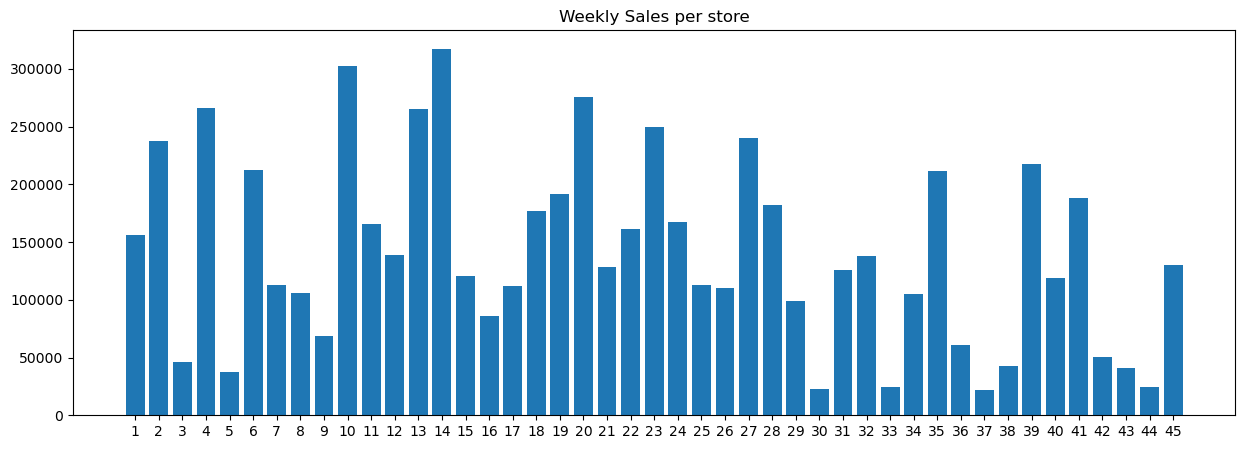

In [18]:
plt.figure(figsize=(15, 5))
plt.bar(WS_std_per_store['Store'], WS_std_per_store['Weekly_Sales'])
plt.xticks(WS_std_per_store['Store'])
plt.title("Weekly Sales per store")
plt.show()

## A/ Store 14 & 10 have the most standard deviation in weekly sales

## Q3/ Some holidays have a negative impact on sales. Find out holidays that have higher sales than the mean sales in the non-holiday season for all stores together.

Holiday Sales:

In [19]:
super_bowl = ['12-02-2010', '11-02-2011', '10-02-2012']
labour_day = ['10-09-2010', '09-09-2011', '07-09-2012']
thanksgiving = ['26-11-2010', '25-11-2011', '23-11-2012']
christmas = ['31-12-2010', '30-12-2011', '28-12-2012']

In [20]:
super_bowl_sales = data.loc[data.Date.isin(super_bowl)]['Weekly_Sales'].mean()
labour_day_sales = data.loc[data.Date.isin(labour_day)]['Weekly_Sales'].mean()
thanksgiving_sales = data.loc[data.Date.isin(thanksgiving)]['Weekly_Sales'].mean()
christmas_sales = data.loc[data.Date.isin(christmas)]['Weekly_Sales'].mean()

Non-holiday sales:

In [21]:
non_holiday_sales = data[(data['Holiday_Flag'] == 0)]['Weekly_Sales'].mean()

In [22]:
sales_comparison = {
    'Super Bowl' : [super_bowl_sales, (super_bowl_sales<non_holiday_sales)],
    'Labour day' : [labour_day_sales, (labour_day_sales<non_holiday_sales)],
    'Thanksgiving' : [thanksgiving_sales, (thanksgiving_sales<non_holiday_sales)],
    'Christmas' : [christmas_sales, (christmas_sales<non_holiday_sales)]
}

Comparing the holiday sales with the non-holiday sales:

In [23]:
sales_comparison = pd.DataFrame(sales_comparison).T
sales_comparison.columns = ['Holiday sales', 'Negative impact']
sales_comparison

,Holiday sales,Negative impact
Super Bowl,1079127.987704,False
Labour day,1042427.293926,False
Thanksgiving,1471273.427778,False
Christmas,960833.111556,True


## A/ Only christmas has negative impact on sales

## Q4/ Provide a monthly and semester view of sales in units and give insights.

In [24]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(2)
memory usage: 402.3 KB


In [25]:
data['Month'] = pd.DatetimeIndex(data['Date']).month
data

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Month
0,1,2010-05-02,1643690.90,0,42.31,2.572,211.096358,8.106,5
1,1,2010-12-02,1641957.44,1,38.51,2.548,211.242170,8.106,12
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2
4,1,2010-05-03,1554806.68,0,46.50,2.625,211.350143,8.106,5
...,...,...,...,...,...,...,...,...,...
6430,45,2012-09-28,713173.95,0,64.88,3.997,192.013558,8.684,9
6431,45,2012-05-10,733455.07,0,64.89,3.985,192.170412,8.667,5
6432,45,2012-12-10,734464.36,0,54.47,4.000,192.327265,8.667,12
6433,45,2012-10-19,718125.53,0,56.47,3.969,192.330854,8.667,10


In [26]:
monthly_sales = data.groupby('Month')['Weekly_Sales'].mean().to_frame().reset_index()
monthly_sales

,Month,Weekly_Sales
0,1,9.476139e+05
1,2,1.054597e+06
2,3,1.024975e+06
3,4,1.024324e+06
4,5,1.035379e+06
5,6,1.064848e+06
6,7,1.014212e+06
7,8,1.044874e+06
8,9,1.009457e+06
9,10,1.030631e+06


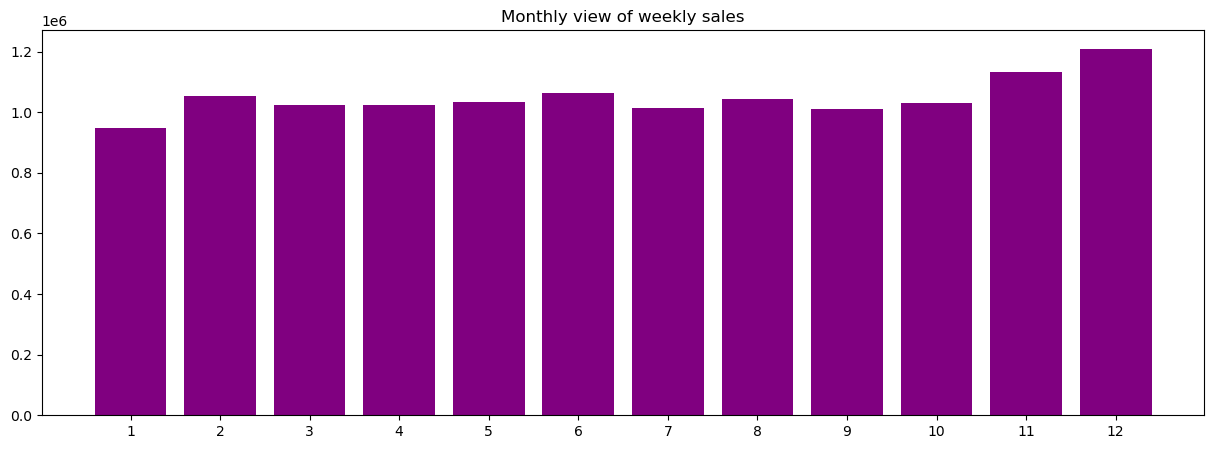

In [27]:
plt.figure(figsize=(15, 5))
plt.bar(monthly_sales['Month'], monthly_sales['Weekly_Sales'], color='purple')
plt.xticks(monthly_sales['Month'])
plt.title('Monthly view of weekly sales')
plt.show()

## A/ December has the highest average sales

In [28]:
first_semester_df = data[data['Date'].dt.month.isin(range(5))]
first_semester_sales = first_semester_df['Weekly_Sales'].sum()
first_semester_sales

2147262247.13

In [29]:
second_semester_df = data[data['Date'].dt.month.isin(range(5, 9))]
second_semester_sales = second_semester_df['Weekly_Sales'].sum()
second_semester_sales

2338260192.65

In [30]:
third_semester_df = data[data['Date'].dt.month.isin(range(9, 13))]
third_semester_sales = third_semester_df['Weekly_Sales'].sum()
third_semester_sales

2251696547.33

In [31]:
semester_df = pd.DataFrame([first_semester_sales, second_semester_sales, third_semester_sales])
semester_df.index = ["first_semester_sales", "second_semester_sales", "third_semester_sales"]
semester_df.columns = ['Sales']
semester_df

,Sales
first_semester_sales,2.147262e+09
second_semester_sales,2.338260e+09
third_semester_sales,2.251697e+09


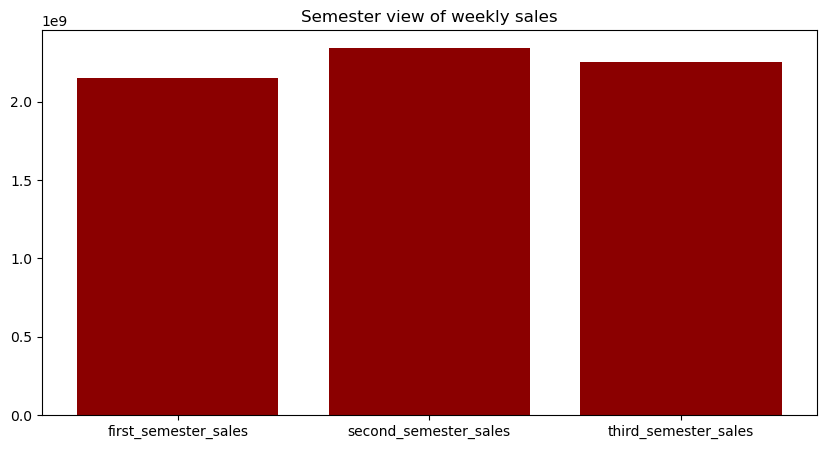

In [32]:
plt.figure(figsize=(10, 5))
plt.bar(semester_df.index, semester_df['Sales'], color='DarkRed')
plt.xticks(semester_df.index)
plt.title('Semester view of weekly sales')
plt.show()

## A/ Second semester sales are usually higher

## Q5/ Plot the relations between weekly sales vs. other numeric features and give insights.

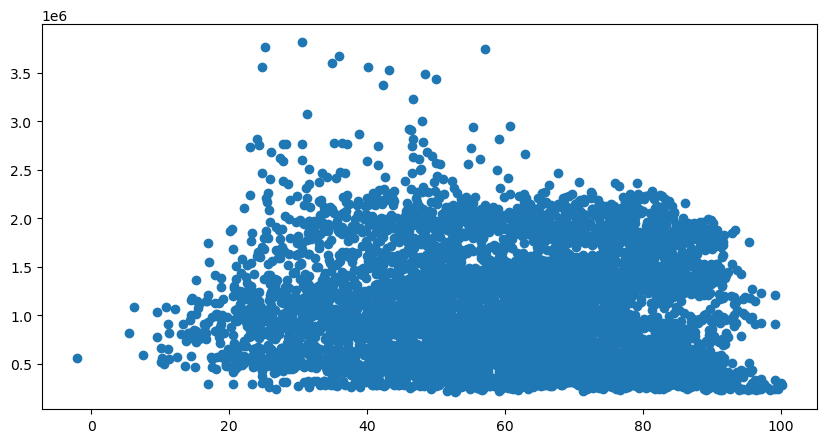

In [33]:
plt.figure(figsize = (10, 5))
plt.scatter(data['Temperature'], data['Weekly_Sales'])
plt.show()

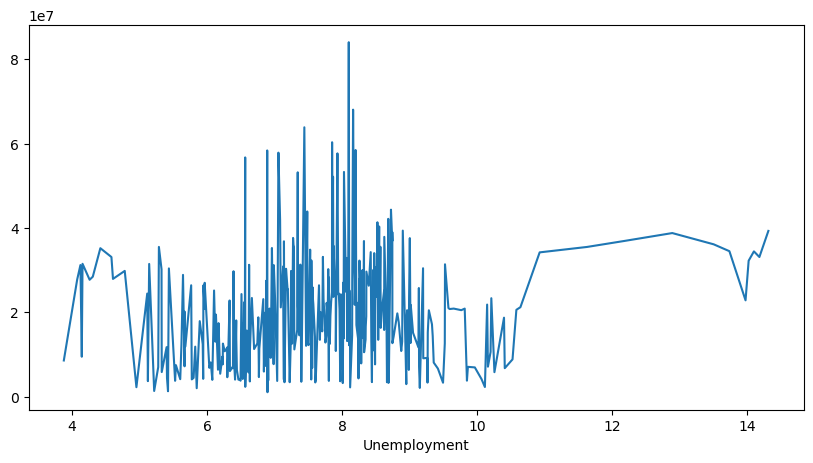

In [34]:
plt.figure(figsize = (10, 5))
data.groupby('Unemployment')['Weekly_Sales'].sum().plot(kind = 'line')
plt.show()

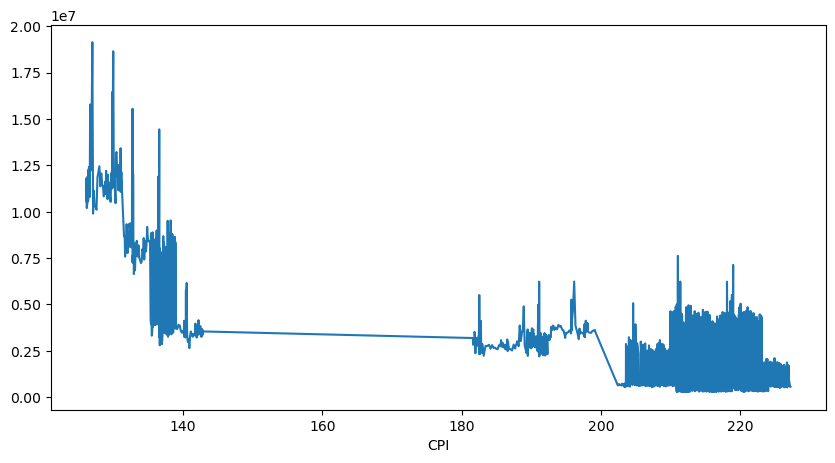

In [35]:
plt.figure(figsize = (10, 5))
data.groupby('CPI')['Weekly_Sales'].sum().plot(kind = 'line')
plt.show()

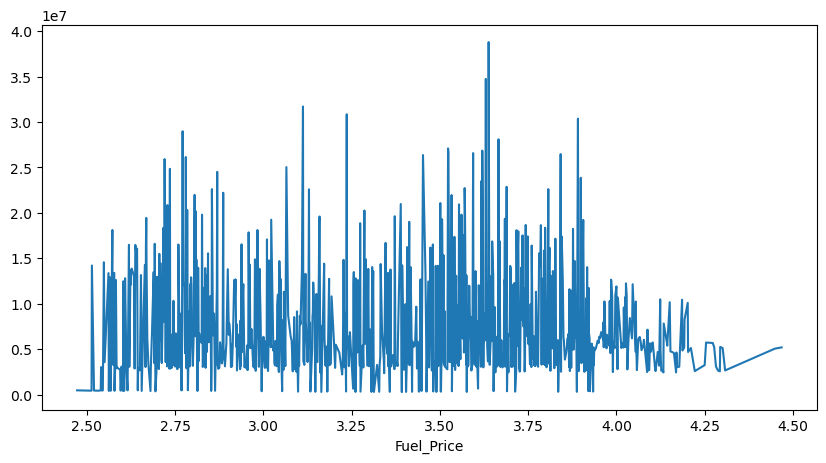

In [36]:
plt.figure(figsize = (10, 5))
data.groupby('Fuel_Price')['Weekly_Sales'].sum().plot(kind = 'line')
plt.show()

## A/ CPI has negative effect on sales

# تم بحمد الله